# 🛵 Cohort Analysis — Ride Hailing Transactions
**Level:** Beginner → Intermediate  
**Topik:** Cohort Analysis · Retention Heatmap · Business Insight (OIR)

---
## 🎯 Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kamu diharapkan mampu:
1. Memahami konsep **cohort** dan kapan digunakan dalam analitik bisnis
2. Melakukan **data preparation** dari dataset multi-tabel
3. Membuat **cohort assignment** berdasarkan *first ride month*
4. Menghitung **cohort index** (periode ke-N sejak bergabung)
5. Memvisualisasikan **retention heatmap**
6. Menulis **business insight** menggunakan framework **Observasi → Interpretasi → Rekomendasi (OIR)**

---
## 🏢 Konteks Bisnis

Kamu adalah seorang **Data Analyst** di perusahaan ride-hailing global.  
Tim Growth ingin memahami:

> *"Dari semua user yang pertama kali menggunakan layanan pada bulan tertentu,*  
> *berapa persen yang masih aktif di bulan-bulan berikutnya?"*

Pertanyaan ini dijawab dengan **Cohort Analysis berbasis akuisisi (acquisition cohort)**.

---
## 📦 Dataset

Kamu memiliki **4 file dataset**:

| File | Deskripsi | Key Column |
|---|---|---|
| `users.csv` | Data 11.000 pengguna terdaftar | `user_id`, `created_at` |
| `drivers.csv` | Data 1.000 driver | `driver_id` |
| `fact_rides.csv` | 25.000+ transaksi perjalanan | `customer_id`, `ride_date`, `fare_amount` |
| `vouchers.csv` | Data voucher diskon | `voucher_code`, `discount_perc` |

---
## Section 0 — Setup & Load Data

### 📌 Penjelasan
Import semua library yang dibutuhkan dan load keempat file dataset.


In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120

### ❓ Soal 0.1
Load keempat file CSV ke dalam DataFrame. Perhatikan:
- `users.csv`, `drivers.csv`, `fact_rides.csv` menggunakan **separator titik koma** (`;`)
- `vouchers.csv` menggunakan **separator koma** (`,`)
- Gunakan parameter `on_bad_lines='skip'` pada `fact_rides.csv`


In [5]:
# Soal 0.1 — Load semua dataset
users    = pd.read_csv('users.csv',      sep=";")
drivers  = pd.read_csv('drivers.csv',    sep=";")
rides    = pd.read_csv('fact_rides.csv', sep=";", on_bad_lines='skip')
vouchers = pd.read_csv('vouchers.csv')

print(f'users    : {users.shape}')
print(f'drivers  : {drivers.shape}')
print(f'rides    : {rides.shape}')
print(f'vouchers : {vouchers.shape}')

users    : (11000, 9)
drivers  : (1000, 9)
rides    : (25003, 15)
vouchers : (1000, 6)


In [6]:
# Preview masing-masing tabel
display(users.head(3))
display(drivers.head(3))
display(rides.head(3))
display(vouchers.head(3))

,user_id,username,last_name,first_name,email,password_hash,phone_number,gender,created_at
0,1,itruder0,Truder,Indira,itruder0@arstechnica.com,$2a$04$C6ECr/QghWNgrQ8qEt8m7OJFy.IrsGJhcNMhyy2...,545-943-3541,Genderqueer,6/19/2024
1,2,sickeringill1,Ickeringill,Sinclare,sickeringill1@ning.com,$2a$04$KnCTVfAyRphY7g.xo5eUrOj1NM8bt4R4tyZXd0f...,474-234-0074,Male,3/30/2024
2,3,bhalwill2,Halwill,Blayne,bhalwill2@nyu.edu,$2a$04$PzgA8zkaE35/PCHTH7HrcO17TQoZppJcW9ec8Av...,701-915-6457,Male,4/22/2024


,driver_id,first_name,last_name,email,phone_number,car_make,car_model,license_plate,created_at
0,1,Noellyn,De Beauchamp,ndebeauchamp0@home.pl,884-707-5045,Mazda,B-Series Plus,PSS-3992,8/20/2024
1,2,Rayner,Christon,rchriston1@stanford.edu,120-163-5854,Ford,Mustang,VVS-3204,3/23/2024
2,3,Beaufort,Tebbut,btebbut2@clickbank.net,863-667-3548,Nissan,Altima,NPX-9584,07/05/2024


,ride_id,customer_id,driver_id,start_location,end_location,city,country,ride_date,ride_time,ride_duration_minutes,fare_amount,ride_distance_miles,payment_method,voucher,rating
0,5883.00,242.00,353.00,9 Ohio Avenue,2087 Oak Crossing,Lubień,Poland,10/11/2024,21:18,14.00,97.15,6.80,cash,NaN,5.00
1,7978.00,7660.00,861.00,017 Raven Hill,1 Rockefeller Lane,Springfield,United States,1/21/2024,08:13,63.00,11.54,8.90,credit card,NaN,3.00
2,7765.00,1235.00,892.00,60542 La Follette Road,3 Blackbird Pass,Ob’,Russia,5/25/2024,13:38,52.00,41.04,0.80,cash,NaN,4.00


,voucher_code,discount_amount,start_date,end_date,updated_at,discount_perc
0,XYZ456,79.10,1733626547,1734299250,1735835399,11
1,456JKL,46.32,1733586920,1734408835,1735232964,14
2,789VWX,74.62,1729519466,1731580427,1731798243,12


---
## Section 1 — Data Overview & Quality Check

### 📌 Penjelasan
Sebelum analisis, kita perlu memahami struktur dan kualitas masing-masing tabel.

---
### ❓ Soal 1.1
Tampilkan `.info()` dari `rides` dan `users`. Identifikasi kolom yang perlu dikonversi tipe datanya.

In [16]:
# Soal 1.1a — Info tabel rides
# TODO: tampilkan info rides
rides.info()

<class 'pandas.DataFrame'>
RangeIndex: 25003 entries, 0 to 25002
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ride_id                25000 non-null  float64
 1   customer_id            25000 non-null  float64
 2   driver_id              25000 non-null  float64
 3   start_location         25000 non-null  str    
 4   end_location           25000 non-null  str    
 5   city                   25000 non-null  str    
 6   country                25000 non-null  str    
 7   ride_date              25000 non-null  str    
 8   ride_time              25000 non-null  str    
 9   ride_duration_minutes  25000 non-null  float64
 10  fare_amount            25000 non-null  float64
 11  ride_distance_miles    25000 non-null  float64
 12  payment_method         25000 non-null  str    
 13  voucher                7547 non-null   str    
 14  rating                 25000 non-null  float64
dtypes: float64(7)

In [8]:
# Soal 1.1b — Info tabel users
# TODO: tampilkan info users
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        11000 non-null  int64
 1   username       11000 non-null  str  
 2   last_name      11000 non-null  str  
 3   first_name     11000 non-null  str  
 4   email          11000 non-null  str  
 5   password_hash  11000 non-null  str  
 6   phone_number   9582 non-null   str  
 7   gender         11000 non-null  str  
 8   created_at     11000 non-null  str  
dtypes: int64(1), str(8)
memory usage: 773.6 KB


### ❓ Soal 1.2
Cek **missing values** pada tabel `rides`. Kolom mana yang memiliki data kosong terbanyak?
> 💡 Hint: `.isnull().sum().sort_values(ascending=False)`

In [20]:
# Soal 1.2 — Missing values di tabel rides
missing_rides = rides.isnull().sum().sort_values(ascending=False)
print(missing_rides[missing_rides > 0])

voucher                  17456
customer_id                  3
ride_id                      3
start_location               3
end_location                 3
city                         3
driver_id                    3
country                      3
ride_date                    3
ride_duration_minutes        3
ride_time                    3
fare_amount                  3
ride_distance_miles          3
payment_method               3
rating                       3
dtype: int64


### ❓ Soal 1.3
Tampilkan statistik deskriptif kolom `fare_amount`, `ride_duration_minutes`, dan `rating` dari tabel `rides`.

In [21]:
# Soal 1.3 — Statistik deskriptif
rides[["fare_amount", "ride_duration_minutes", "rating"]].describe()

,fare_amount,ride_duration_minutes,rating
count,25000.00,25000.00,25000.00
mean,52.57,62.44,3.93
std,27.48,33.53,0.92
min,5.00,5.00,1.00
25%,28.77,33.00,3.00
50%,52.57,62.00,4.00
75%,76.27,92.00,5.00
max,99.99,120.00,5.00


### ❓ Soal 1.4
Berapa distribusi `payment_method` dalam tabel `rides`? Tampilkan sebagai **value counts**.

In [22]:
# Soal 1.4 — Distribusi payment method
rides["payment_method"].value_counts()

payment_method
cash             8413
credit card      8334
mobile wallet    8253
Name: count, dtype: int64

---
## Section 2 — Data Preprocessing

### 📌 Penjelasan
Untuk cohort analysis kita perlu:
1. Konversi kolom tanggal ke tipe **datetime**
2. Ekstrak **bulan** dari tanggal (format `Period` `YYYY-MM`)
3. Membersihkan data yang tidak diperlukan

> 💡 **Tip:** Gunakan `pd.to_datetime()` dan `.dt.to_period('M')`

---
### ❓ Soal 2.1
Konversi kolom `ride_date` pada tabel `rides` dari string ke **datetime**.

In [25]:
# Soal 2.1 — Konversi ride_date ke datetime
rides['ride_date'] = pd.to_datetime(rides["ride_date"])

# Verifikasi
print('Tipe data ride_date :', rides['ride_date'].dtype)
print('Rentang tanggal     :', rides['ride_date'].min(), '->', rides['ride_date'].max())

Tipe data ride_date : datetime64[us]
Rentang tanggal     : 2024-01-01 00:00:00 -> 2025-01-09 00:00:00


### ❓ Soal 2.2
Konversi kolom `created_at` pada tabel `users` ke **datetime**.

In [26]:
# Soal 2.2 — Konversi created_at di users
users['created_at'] =pd.to_datetime(users["created_at"])

print('Tipe data created_at:', users['created_at'].dtype)

Tipe data created_at: datetime64[us]


### ❓ Soal 2.3
Buat kolom `ride_month` pada tabel `rides` yang berisi **bulan transaksi** dalam format `Period` (contoh: `2024-01`).

In [31]:
# Soal 2.3 — Buat kolom ride_month
rides['ride_month'] = rides["ride_date"].dt.to_period("M")

rides[['customer_id', 'ride_date', 'ride_month']].head(5)

,customer_id,ride_date,ride_month
0,242.00,2024-10-11,2024-10
1,7660.00,2024-01-21,2024-01
2,1235.00,2024-05-25,2024-05
3,10548.00,2024-06-29,2024-06
4,3087.00,2024-05-13,2024-05


### ❓ Soal 2.4
Hapus baris pada `rides` di mana `customer_id` bernilai **NaN** (kosong).  
Simpan hasilnya kembali ke variabel `rides`, lalu reset index.

> 💡 Hint: `.dropna(subset=['customer_id'])`

In [37]:
# Soal 2.4 — Drop baris dengan customer_id kosong
rides = rides.dropna(subset=["customer_id"]).reset_index(drop=True)

# Konversi customer_id ke integer
rides['customer_id'] = rides['customer_id'].astype(int)

print(f'Jumlah rides setelah cleaning: {len(rides):,}')

Jumlah rides setelah cleaning: 25,000


---
## Section 3 — Cohort Assignment

### 📌 Konsep: Apa itu Cohort?

> **Cohort** = sekelompok user yang melakukan *first ride* pada **periode yang sama**.

| Cohort | Siapa yang termasuk? |
|---|---|
| **Cohort Jan 2024** | User yang *pertama kali* naik pada Januari 2024 |
| **Cohort Feb 2024** | User yang *pertama kali* naik pada Februari 2024 |
| **Cohort Mar 2024** | User yang *pertama kali* naik pada Maret 2024 |

Dengan mengelompokkan user ke dalam cohort, kita bisa membandingkan perilaku  
kelompok yang berbeda secara *apples-to-apples*.

---
### ❓ Soal 3.1
Untuk setiap `customer_id`, temukan **bulan pertama kali mereka melakukan ride** (`cohort_month`).

> 💡 Hint: `df.groupby('customer_id')['ride_month'].min()`

In [38]:
# Soal 3.1 — Tentukan cohort_month (first ride month) per customer
cohort_df = rides.groupby("customer_id")["ride_month"].min().reset_index()
cohort_df.columns = ['customer_id', 'cohort_month']

print(f'Total customer unik: {len(cohort_df):,}')
cohort_df.head(8)

Total customer unik: 9,934


,customer_id,cohort_month
0,1,2024-01
1,2,2024-08
2,3,2024-04
3,4,2024-03
4,5,2024-03
5,6,2024-04
6,7,2024-06
7,8,2024-02


### ❓ Soal 3.2
Gabungkan (`merge`) kolom `cohort_month` dari `cohort_df` ke tabel `rides`,  
sehingga setiap baris transaksi memiliki informasi cohort customernya.

In [40]:
# Soal 3.2 — Merge cohort_month ke rides
rides = pd.merge(rides, cohort_df, on="customer_id", how="left")

rides[['customer_id', 'ride_date', 'ride_month', 'cohort_month']].head(6)

,customer_id,ride_date,ride_month,cohort_month
0,242,2024-10-11,2024-10,2024-07
1,7660,2024-01-21,2024-01,2024-01
2,1235,2024-05-25,2024-05,2024-05
3,10548,2024-06-29,2024-06,2024-05
4,3087,2024-05-13,2024-05,2024-05
5,7880,2024-01-17,2024-01,2024-01


### ❓ Soal 3.3
Hitung **jumlah customer baru per cohort_month** (cohort size).  
Urutkan dari yang terbesar ke terkecil dan tampilkan hasilnya.

In [41]:
# Soal 3.3 — Cohort size per bulan
cohort_size_tbl = rides.groupby("cohort_month")["customer_id"].nunique().reset_index()
cohort_size_tbl.columns = ['cohort_month', 'new_customers']
cohort_size_tbl = cohort_size_tbl.sort_values('new_customers', ascending=False)

print(cohort_size_tbl.to_string(index=False))

cohort_month  new_customers
     2024-01           1855
     2024-02           1479
     2024-03           1339
     2024-04           1079
     2024-05            935
     2024-06            729
     2024-07            620
     2024-08            499
     2024-09            391
     2024-10            386
     2024-11            318
     2024-12            240
     2025-01             64


---
## Section 4 — Cohort Index (Period Number)

### 📌 Konsep: Period Number

**Period number** = selisih antara `ride_month` dan `cohort_month` dalam satuan bulan.

| cohort_month | ride_month | period_number | Artinya |
|---|---|---|---|
| 2024-01 | 2024-01 | **0** | Bulan pertama (bulan join) |
| 2024-01 | 2024-02 | **1** | 1 bulan setelah join |
| 2024-01 | 2024-05 | **4** | 4 bulan setelah join |

Period 0 selalu berisi 100% karena itu adalah bulan pertama user menggunakan layanan.

---
### ❓ Soal 4.1
Hitung kolom `period_number` untuk setiap baris transaksi.

> 💡 Hint: Objek `Period` pandas bisa dikurangi. Gunakan `.apply(lambda x: x.n)` untuk ambil nilai integer.

In [44]:
# Soal 4.1 — Hitung period_number
rides['period_number'] = (rides['ride_month'] - rides['cohort_month']).apply(lambda x:x.n)

# Preview hasilnya
rides[['customer_id', 'cohort_month', 'ride_month', 'period_number']].drop_duplicates().head(10)

,customer_id,cohort_month,ride_month,period_number
0,242,2024-07,2024-10,3
1,7660,2024-01,2024-01,0
2,1235,2024-05,2024-05,0
3,10548,2024-05,2024-06,1
4,3087,2024-05,2024-05,0
5,7880,2024-01,2024-01,0
6,6711,2024-02,2024-02,0
7,8315,2024-03,2024-08,5
8,2838,2024-11,2024-12,1
9,10523,2024-02,2024-11,9


### ❓ Soal 4.2 (Eksplorasi)
Berapa **period_number maksimum** yang ada di data? Berapa bulan rentang observasi kita?

In [45]:
# Soal 4.2 — Cek rentang period_number
print(f'Period number min : {rides["period_number"].min()}')
print(f'Period number max : {rides["period_number"].max()}')
print(f'Jumlah periode    : {rides["period_number"].nunique()}')

Period number min : 0
Period number max : 12
Jumlah periode    : 13


---
## Section 5 — Retention Matrix & Heatmap

### 📌 Konsep: Retention Matrix

```
Retention Rate (%) = Jumlah user aktif di period N  x 100%
                     ─────────────────────────────
                     Jumlah user di period 0 (cohort size)
```

Struktur tabel:
- **Baris** → cohort_month (bulan akuisisi)
- **Kolom** → period_number (0 = bulan join, 1 = bulan berikutnya, dst.)
- **Nilai** → persentase user yang masih aktif

---
### ❓ Soal 5.1
Buat **pivot table** yang menghitung jumlah *unique* `customer_id` aktif  
per kombinasi `cohort_month` dan `period_number`.

In [46]:
# Soal 5.1 — Pivot table: jumlah user aktif
cohort_pivot = rides.groupby(['cohort_month', 'period_number'])['customer_id'] \
                    .nunique() \
                    .reset_index() \
                    .pivot(index="cohort_month", columns="period_number", values="customer_id")

cohort_pivot.columns.name = None
print(f'Shape pivot table: {cohort_pivot.shape}')
cohort_pivot.iloc[:5, :8]  # preview 5 cohort, 8 periode

Shape pivot table: (13, 13)


,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2024-01,1855.00,286.00,331.00,313.00,300.00,292.00,288.00,319.00
2024-02,1479.00,250.00,228.00,264.00,251.00,259.00,248.00,268.00
2024-03,1339.00,196.00,203.00,221.00,237.00,253.00,219.00,239.00
2024-04,1079.00,190.00,163.00,185.00,182.00,162.00,170.00,182.00
2024-05,935.00,144.00,181.00,157.00,154.00,151.00,131.00,153.00


### ❓ Soal 5.2
Konversi pivot table ke **persentase retention** dengan membagi setiap baris  
terhadap nilai di kolom `0` (cohort size).

In [48]:
# Soal 5.2 — Konversi ke persentase retention
cohort_size_per_cohort = cohort_pivot[0]  # ambil kolom period 0
retention_matrix = cohort_pivot.divide(cohort_pivot, axis=0).round(4) * 100

# Preview
retention_matrix.iloc[:5, :8]

,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2024-01,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2024-02,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2024-03,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2024-04,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2024-05,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


### ❓ Soal 5.3 — Retention Heatmap
Visualisasikan `retention_matrix` sebagai heatmap menggunakan Seaborn.

**Spesifikasi:**
- `annot=True`, `fmt='.1f'` → tampilkan angka persen
- `cmap='YlOrRd_r'` → hijau = tinggi, merah = rendah
- `vmin=0`, `vmax=100` → skala warna 0–100%
- Tambahkan judul dan label sumbu yang jelas

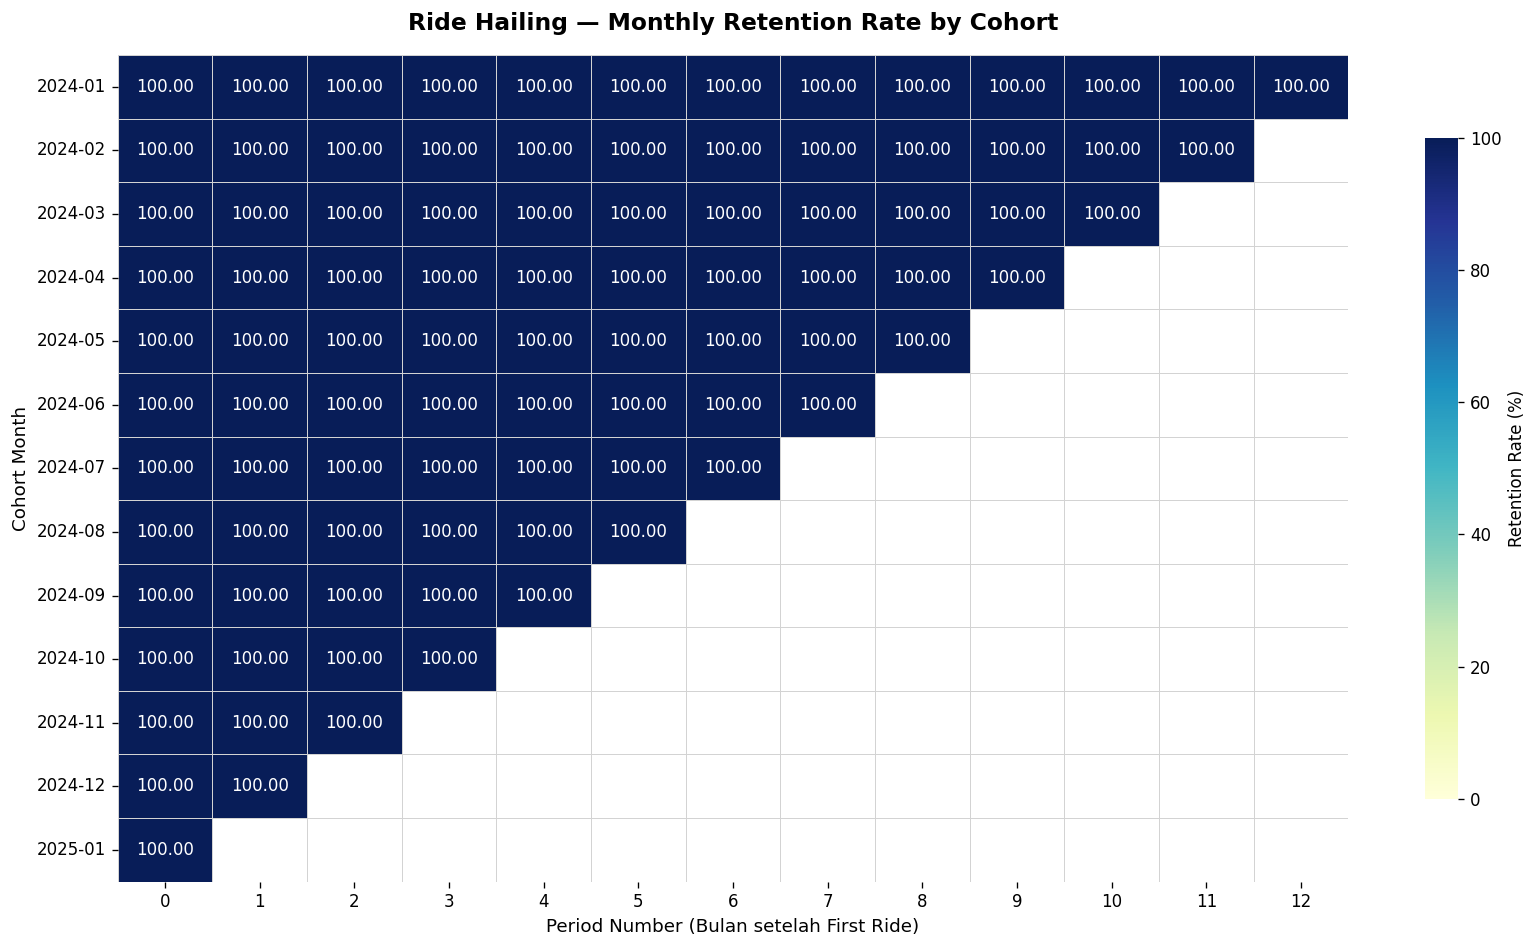

In [49]:
# Soal 5.3 — Retention Heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    data = retention_matrix,
    annot=True,
    fmt='.2f',
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='lightgrey',
    vmin=0, vmax=100,
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)', 'shrink': 0.8}
)

ax.set_title('Ride Hailing — Monthly Retention Rate by Cohort',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Period Number (Bulan setelah First Ride)', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)

plt.tight_layout()
plt.show()

### ❓ Soal 5.4 — Cohort Size Bar Chart
Visualisasikan **jumlah customer baru per cohort month** sebagai bar chart  
agar kita tahu seberapa besar tiap cohort sebelum membaca retention-nya.

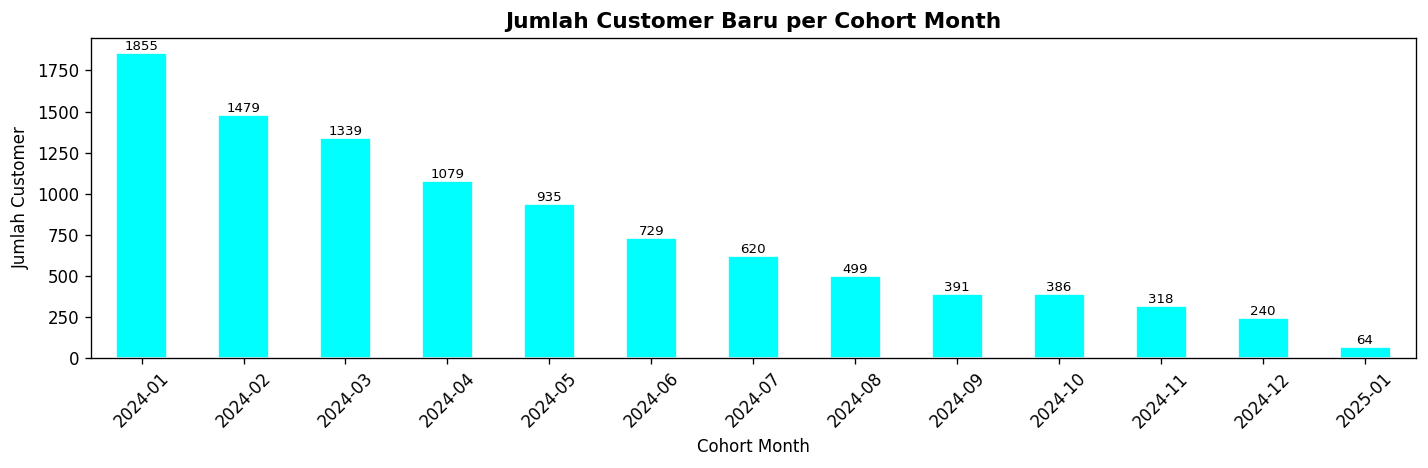

In [54]:
# Soal 5.4 — Bar chart cohort size
fig, ax = plt.subplots(figsize=(12, 4))

# TODO: plot cohort_size_per_cohort sebagai bar chart
cohort_size_per_cohort.plot(kind="bar", ax=ax, color='cyan', edgecolor='white')

ax.set_title('Jumlah Customer Baru per Cohort Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Jumlah Customer')
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 6 — Analisis Lanjutan (Opsional)

### 📌 Penjelasan
Selain retention berbasis user count, kita bisa menganalisis **revenue cohort** —  
yaitu total pendapatan (`fare_amount`) yang dihasilkan per cohort di setiap periode.

---
### ❓ Soal 6.1 — Revenue per Cohort
Buat pivot table yang menghitung **total `fare_amount`** per `cohort_month` dan `period_number`  
(gunakan `aggfunc='sum'` atau `.sum()`).

In [55]:
# Soal 6.1 — Revenue cohort pivot
revenue_pivot = rides.groupby(['cohort_month', 'period_number'])['fare_amount'] \
                     .sum() \
                     .reset_index() \
                     .pivot(index='cohort_month', columns='period_number', values='fare_amount')

revenue_pivot.columns.name = None
revenue_pivot.iloc[:5, :6].round(0)

,0,1,2,3,4,5
cohort_month,,,,,,
2024-01,108616.00,16071.00,19398.00,16925.00,17873.00,16613.00
2024-02,84685.00,14754.00,13432.00,15210.00,14448.00,15551.00
2024-03,77215.00,10600.00,11567.00,11796.00,14043.00,15334.00
2024-04,60503.00,11127.00,9537.00,10500.00,10473.00,8954.00
2024-05,55060.00,8611.00,10391.00,9316.00,8865.00,8427.00


### ❓ Soal 6.2 — Revenue Heatmap
Visualisasikan `revenue_pivot` sebagai heatmap.  
Kali ini tidak perlu dikonversi ke persentase — tampilkan nilai absolut (total fare).

> 💡 Gunakan `fmt='.0f'` dan hapus `vmin/vmax` agar skala otomatis.

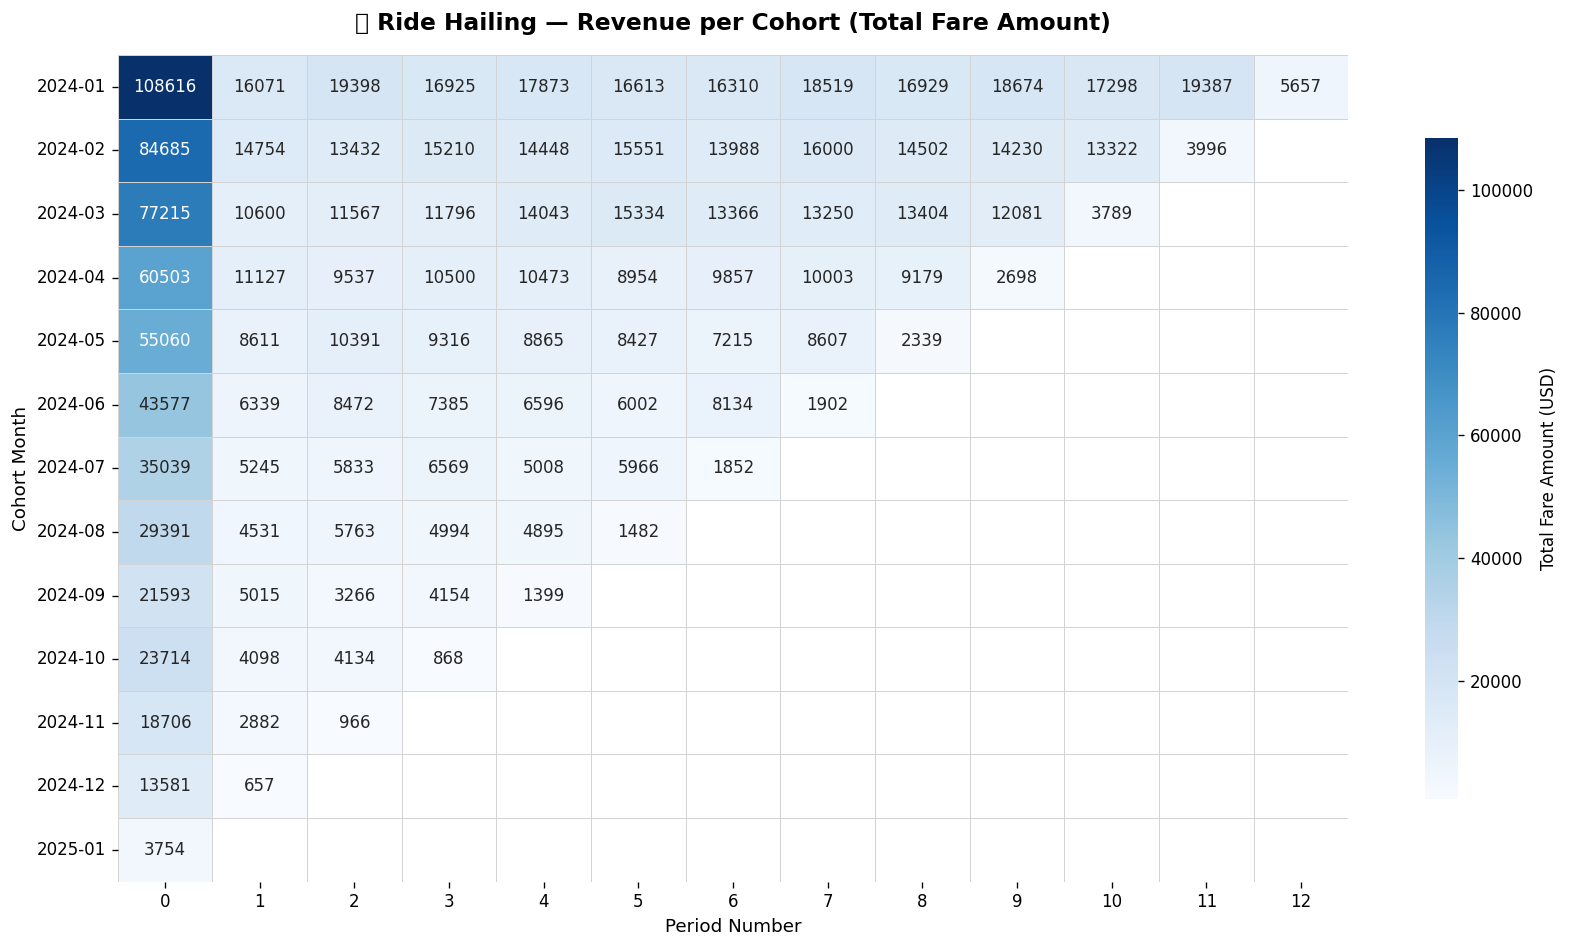

In [56]:
# Soal 6.2 — Revenue Heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    data = revenue_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgrey',
    ax=ax,
    cbar_kws={'label': 'Total Fare Amount (USD)', 'shrink': 0.8}
)

ax.set_title('🛵 Ride Hailing — Revenue per Cohort (Total Fare Amount)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Period Number', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)

plt.tight_layout()
plt.show()

---
## Section 7 — Business Insight (OIR)

### 📌 Framework OIR

| Layer | Pertanyaan kunci | Contoh |
|---|---|---|
| **🔍 Observasi** | Apa yang terlihat dari data/chart? | "Retention period 1 rata-rata X%" |
| **💡 Interpretasi** | Apa maknanya untuk bisnis? | "Artinya, hanya X% user yang kembali bulan berikutnya" |
| **✅ Rekomendasi** | Aksi apa yang sebaiknya diambil? | "Luncurkan re-engagement push notification di hari ke-20" |

---
### ❓ Soal 7.1 — Guided Questions

**a) Overall Retention Trend**  
Apa yang terjadi dengan retention rate dari period 0 ke period 1, 2, 3?  
Seberapa besar penurunannya?

Rata-rata Retention Rate (%) per Period:
0    100.00
1    100.00
2    100.00
3    100.00
4    100.00
5    100.00
6    100.00
7    100.00
8    100.00
9    100.00
10   100.00
11   100.00
12   100.00


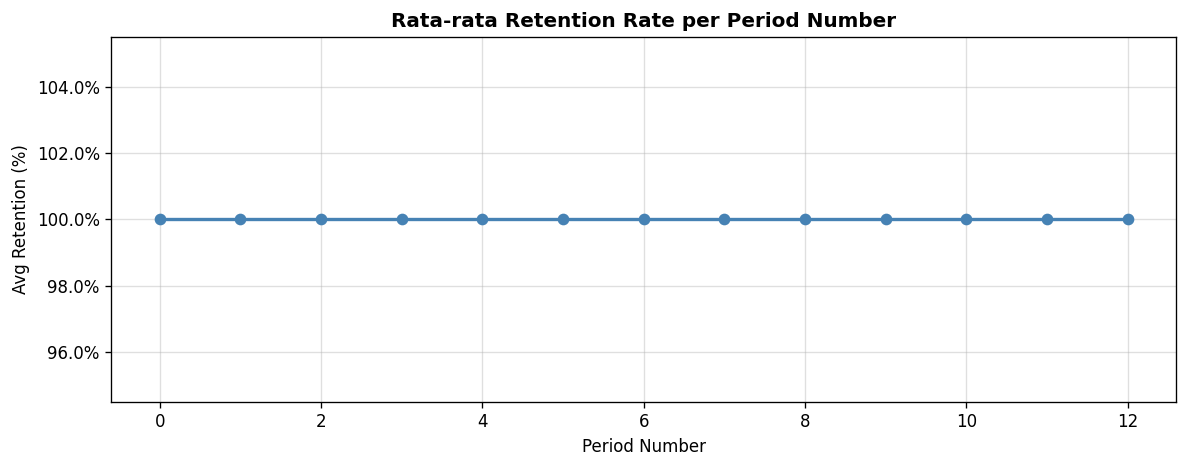

In [57]:
# Helper — Rata-rata retention per period number
avg_retention = retention_matrix.mean().dropna()
print('Rata-rata Retention Rate (%) per Period:')
print(avg_retention.round(1).to_string())

# Visualisasi trend
fig, ax = plt.subplots(figsize=(10, 4))
avg_retention.plot(marker='o', color='steelblue', linewidth=2, ax=ax)
ax.set_title('Rata-rata Retention Rate per Period Number', fontweight='bold')
ax.set_xlabel('Period Number')
ax.set_ylabel('Avg Retention (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

> ✍️ **Jawaban kamu:**  
> *(Tuliskan observasi kamu di sini — sertakan angka dari output di atas!)*

**b) Cohort Terbaik vs Terburuk**  
Cohort bulan mana yang memiliki retention period 1 **tertinggi** dan **terendah**?

In [59]:
# Helper — Retention period 1 per cohort, diurutkan
retention_p1 = retention_matrix[1].sort_values(ascending=False)
print('Retention Rate Period 1 (%) — dari tertinggi ke terendah:')
print(retention_p1.round(1).to_string())

Retention Rate Period 1 (%) — dari tertinggi ke terendah:
cohort_month
2024-01   100.00
2024-02   100.00
2024-03   100.00
2024-04   100.00
2024-05   100.00
2024-06   100.00
2024-07   100.00
2024-08   100.00
2024-09   100.00
2024-10   100.00
2024-11   100.00
2024-12   100.00
2025-01      NaN
Freq: M


> ✍️ **Jawaban kamu:**  
> *(Sebutkan cohort terbaik & terburuk, beserta angkanya)*

**c) Payment Method & Cohort**  
Apakah ada perbedaan distribusi payment method antara customer yang baru join  
vs customer lama (period >= 3)?

In [ ]:
# Helper — Distribusi payment method: customer baru vs lama
new_customers   = rides[rides['period_number'] == 0]['payment_method'].value_counts(normalize=True) * 100
loyal_customers = rides[rides['period_number'] >= 3]['payment_method'].value_counts(normalize=True) * 100

comparison = pd.DataFrame({
    'New (Period 0)': new_customers,
    'Loyal (Period 3+)': loyal_customers
}).round(1)

print(comparison.to_string())

> ✍️ **Jawaban kamu:**  
> *(Tuliskan observasi kamu)*

---
### ❓ Soal 7.2 — Full OIR Insight

Berdasarkan seluruh analisis di atas, tulis **satu insight lengkap** menggunakan framework OIR.  
Bayangkan kamu mempresentasikan ini kepada **Head of Growth**.

---

**🔍 Observasi:**  
> *(Deskripsikan 1–2 temuan spesifik dengan angka nyata dari chart/tabel)*

**💡 Interpretasi:**  
> *(Jelaskan implikasi bisnis dari temuan tersebut)*

**✅ Rekomendasi:**  
> *(Berikan 1–2 aksi konkret yang bisa dilakukan tim Growth/Marketing/Product)*

---

## 🏁 Summary

Selamat! Kamu sudah berhasil menyelesaikan Cohort Analysis end-to-end. 🎉

| Step | Yang Dilakukan |
|---|---|
| ✅ Load & Overview | Load 4 tabel, cek struktur dan kualitas data |
| ✅ Preprocessing | Parsing datetime, ekstrak bulan, cleaning NaN |
| ✅ Cohort Assignment | First ride month per customer via groupby |
| ✅ Period Number | Hitung jarak bulan sejak first ride |
| ✅ Retention Matrix | Pivot table → persentase retention |
| ✅ Heatmap | Visualisasi retention & revenue dengan Seaborn |
| ✅ Business Insight | OIR framework untuk komunikasi temuan |

---
> 📚 **Ide eksplorasi lanjutan:**  
> - Join dengan `users.csv` → analisis retention berdasarkan `gender`  
> - Join dengan `vouchers.csv` → apakah user yang pakai voucher lebih loyal?  
> - Behavioral cohort berdasarkan `payment_method` pertama kali digunakan  
> - Analisis `rating` per cohort → apakah kepuasan berubah seiring waktu?